# GFW to ASTD Evaluation

In [1]:
from backend import *
%load_ext autoreload
%autoreload 2

gfw_path = "D:/Stockage/GFW/"
astd_path = r"D:\Stockage\ASTD"
parquet_path = "../../examples/data/"

months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Periods for load_periods
periods = {
    2016: months,
    2017: months,
    2018: months,
    2019: months,
    2020: months,
}

## Load all data

In [2]:
df_ASTD = load_periods('all_fishing_2016-2020.parquet', source=astd_path, periods= periods, remove_nan_rows="default", usecols="default", progress=True)
df_ASTD["date_time_utc"] = pd.to_datetime(df_ASTD["date_time_utc"])

display(df_ASTD.sample(1))

df_GFW = load_periods_gfw('GFWLIGHT_2016-2020.parquet', source=gfw_path, periods = periods)

display(df_GFW.sample(1))

Loaded period ../../examples/data/all_fishing_2016-2020.parquet, parameters ignored


,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude
6535674,3903,2016-05-17 21:57:17+00:00,Russia,FS Ice Class 1B,Fishing vessels,1000 - 4999 GT,1710.026001,1293,49.400383,75.418892


Loaded data ../../examples/data/GFWLIGHT_2016-2020.parquet, parameters ignored


,date,mmsi,month,grid_lon,grid_lat
157256299,2019-07-24,701006034,2019-07,-628,-459


#### Preprocess data if needed (ASTD is raw in this case)

In [3]:
# df_GFW = load_periods_gfw('gfw_2019_2020.parquet', source=gfw_path, periods = periods)
# df_GFW['date'] = pd.to_datetime(df_GFW['date'])
# float_cols = ['cell_ll_lon', 'cell_ll_lat', 'hours', 'fishing_hours']
# df_GFW[float_cols] = df_GFW[float_cols].astype('float32')

# Create a month field to avoid build_light_multi_track_data and other processes to hang
dt = df_ASTD['date_time_utc'].dt
df_ASTD['month'] = dt.to_period('M')
df_ASTD['date'] = dt.floor('D')

del dt

# Transform ASTD into grids to reduce compute overhead
df_ASTD["grid_lon"] = np.floor(df_ASTD["longitude"] * 10).astype('int16')
df_ASTD["grid_lat"] = np.floor(df_ASTD["latitude"] * 10).astype('int16')

# Aggregating the data by day and by positions
df_astd = df_ASTD[['date', 'shipid', 'grid_lat', 'grid_lon', 'month', 'iceclass', 'sizegroup_gt', 'flagname']].drop_duplicates()
display(df_astd.sample(1))

C:\Users\virtu\AppData\Local\Temp\ipykernel_15552\1274984800.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_ASTD['month'] = dt.to_period('M')


,date,shipid,grid_lat,grid_lon,month,iceclass,sizegroup_gt,flagname
63084781,2020-05-11 00:00:00+00:00,2435,724,255,2020-05,FS Ice Class 1C,1000 - 4999 GT,Norway


### GFW Charts
#### Unique positions for each day - only fishing records

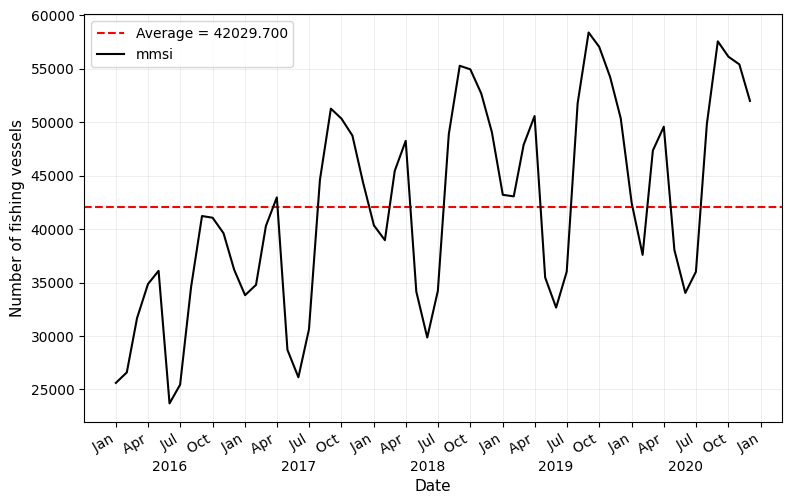

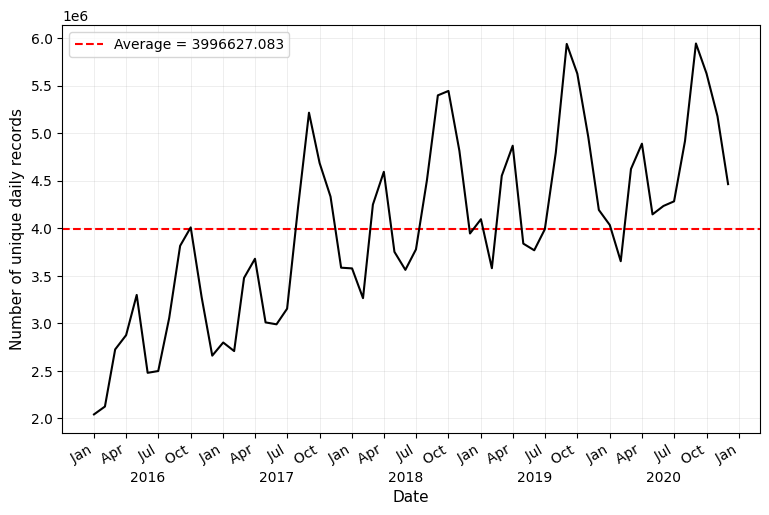

In [4]:
to_plot = df_GFW.groupby('month')['mmsi'].nunique()
evolution_permonth(to_plot, ylabel="Number of fishing vessels", label="GFW-UNIQUE_POS-NO_FILTER")

to_plot = df_GFW.groupby('month').size()
evolution_permonth(to_plot, ylabel="Number of unique daily records", label="GFW-UNIQUE_POS-NO_FILTER")

#### Filter latitude

In [5]:
### FILTER LAT
# Select mmsi with more than a month of data
counts = df_GFW.groupby('mmsi')['month'].nunique()
valid_mmsi = counts[counts > 1].index

gfw_work = df_GFW[df_GFW['mmsi'].isin(valid_mmsi)].copy()

del counts, valid_mmsi

# Filter remove all mmsi with points under europe line - lat = 59: (officialy it is 60, but we want to keep greenland tracks)
gfw_work = filter_latlon(gfw_work, lat=59)

#### Unique positions for each day - only fishing records over latitude selected

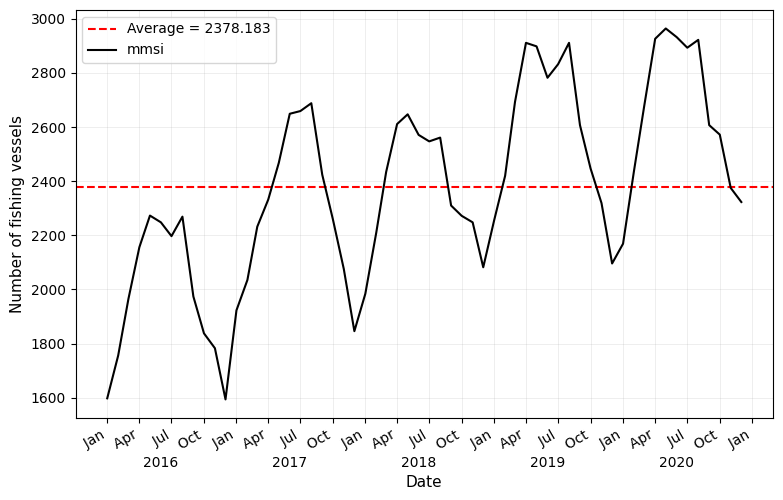

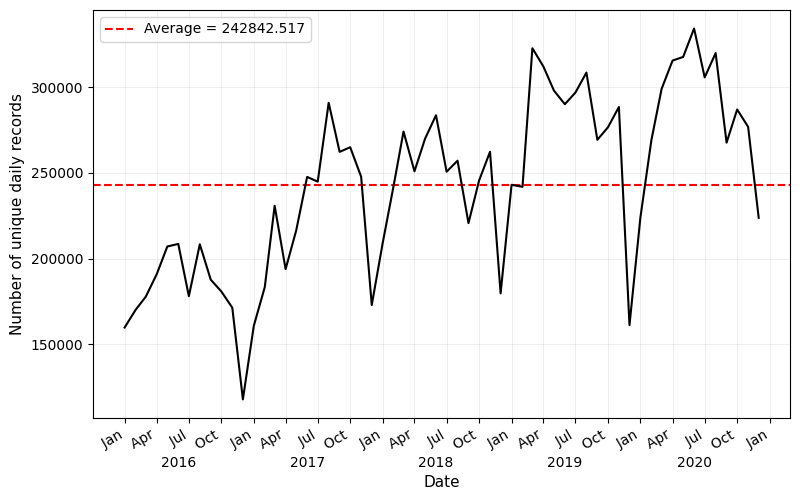

In [6]:
to_plot = gfw_work.groupby('month')['mmsi'].nunique()
evolution_permonth(to_plot, ylabel="Number of fishing vessels", label="GFW-UNIQUE_POS-FILTER")

temp_num_vessels=to_plot

to_plot = gfw_work.groupby('month').size()
evolution_permonth(to_plot, ylabel="Number of unique daily records", label="GFW-UNIQUE_POS-FILTER")

#### Unique positions for each day - number of vessels and number of records together

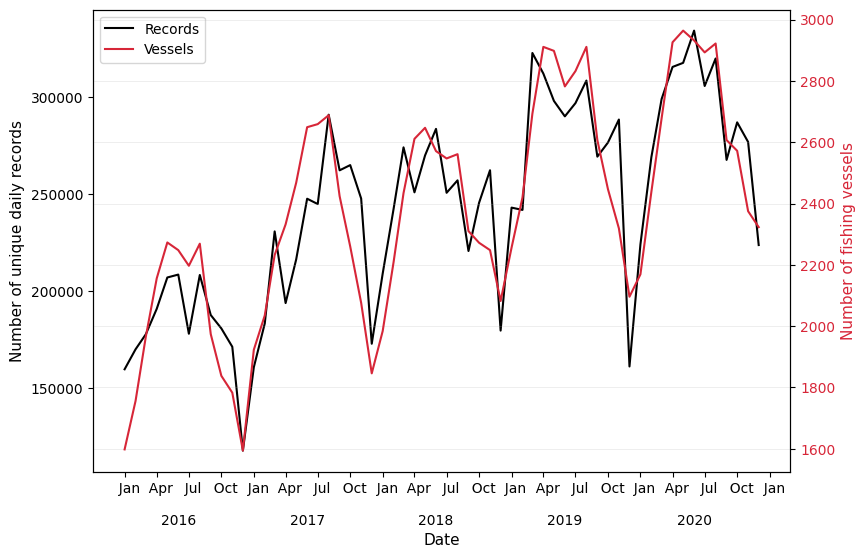

In [7]:
evolution_permonth_both(to_plot, temp_num_vessels, ylabels=["Number of unique daily records", 'Number of fishing vessels'], label="GFW-UNIQUE_POS-FILTER")

### ASTD Charts

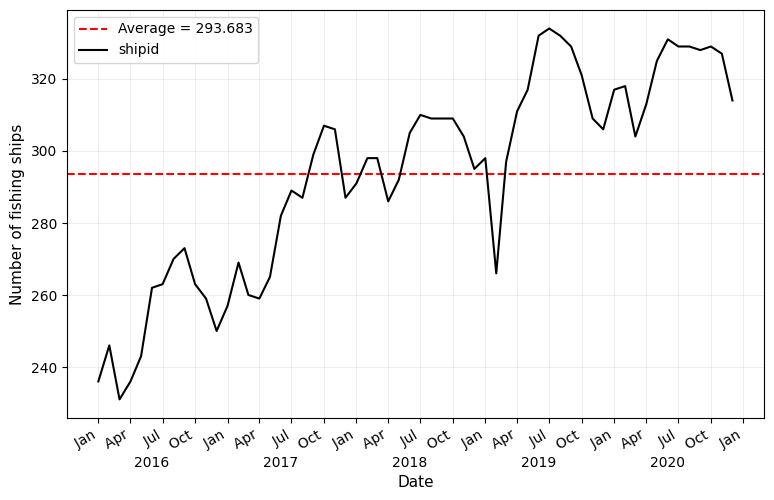

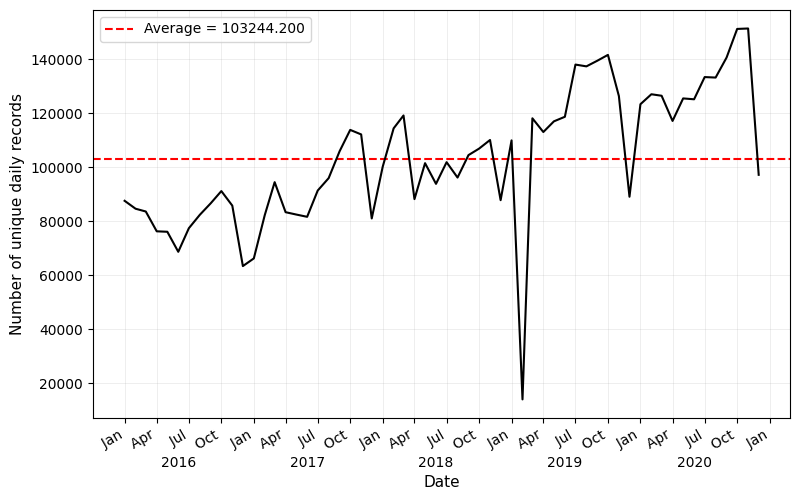

In [8]:
to_plot = df_astd.groupby('month')['shipid'].nunique()
evolution_permonth(to_plot, ylabel="Number of fishing ships", label="ASTD-UNIQUE_POS-NO_FILTER")

to_plot = df_astd.groupby('month').size()
evolution_permonth(to_plot, ylabel="Number of unique daily records", label="ASTD-UNIQUE_POS-NO_FILTER")

In [9]:
### FILTER LAT
# Filter remove all mmsi with points under europe line - lat = 59:
df_astd = filter_latlon(df_astd, lat=59, gfw=False)

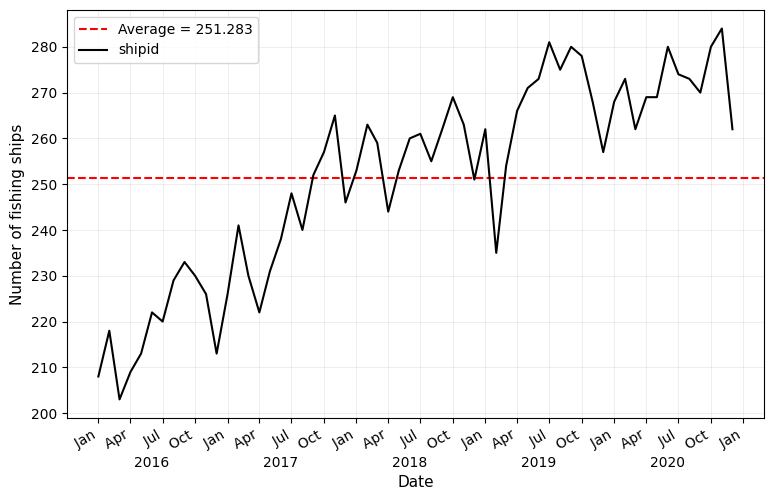

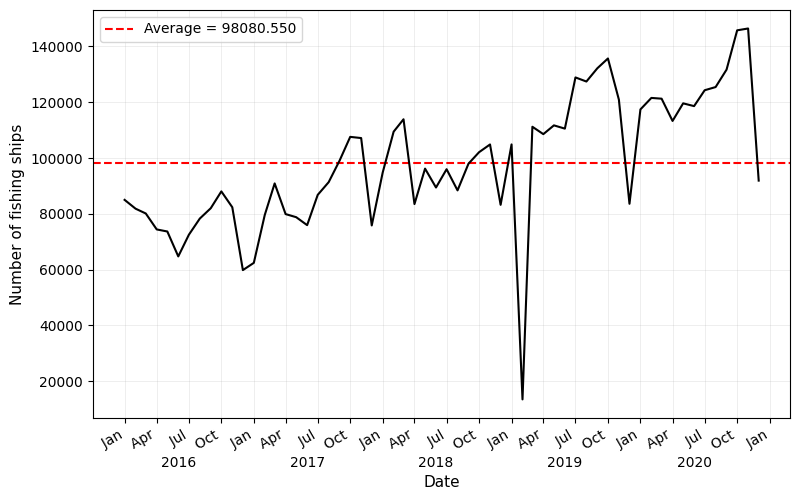

In [10]:
to_plot = df_astd.groupby('month')['shipid'].nunique()
evolution_permonth(to_plot, ylabel="Number of fishing ships", label="ASTD-UNIQUE_POS-FILTER")

temp_num_ships = to_plot

to_plot = df_astd.groupby('month').size()
evolution_permonth(to_plot, ylabel="Number of fishing ships", label="ASTD-UNIQUE_POS-FILTER")

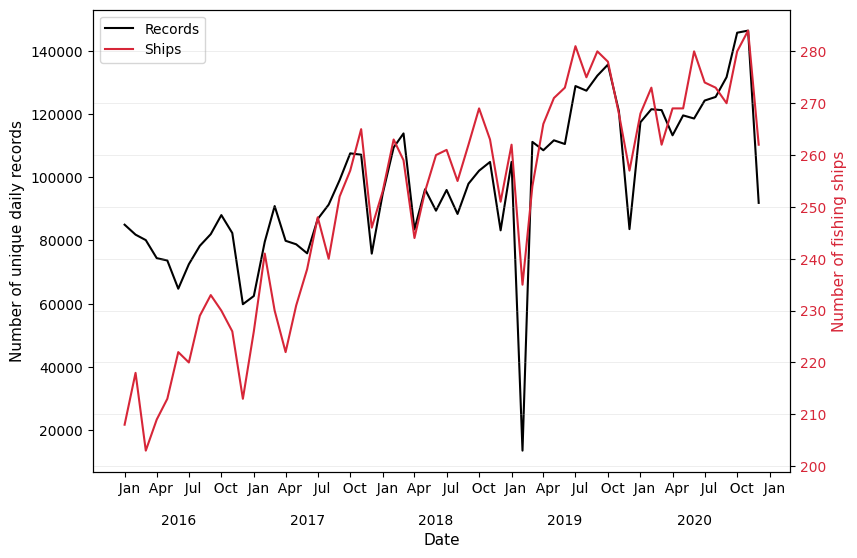

In [11]:
evolution_permonth_both(to_plot, temp_num_ships, ylabels=["Number of unique daily records", 'Number of fishing ships'], label="ASTD-UNIQUE_POS-FILTER")

### Mix between ASTD and GFW charts

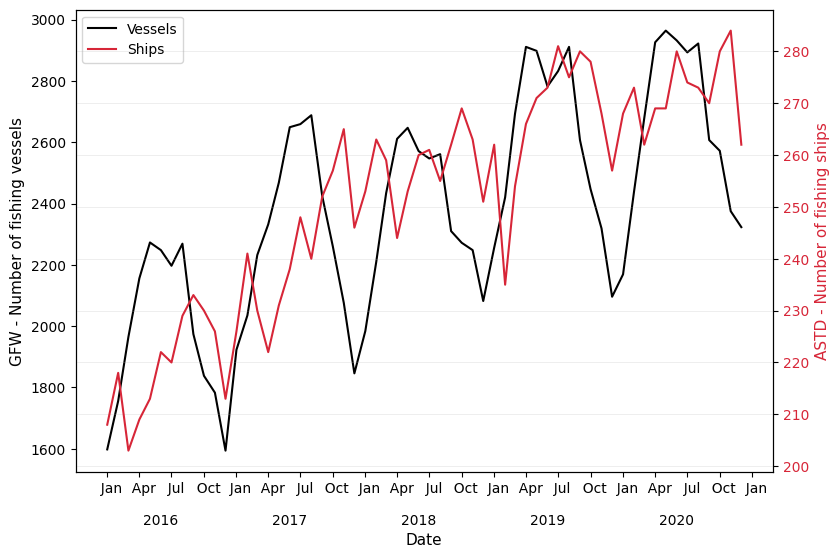

In [12]:
evolution_permonth_both(temp_num_vessels, temp_num_ships, ylabels=["GFW - Number of fishing vessels", 'ASTD - Number of fishing ships'], label="ALL-UNIQUE_POS-FILTER")

### Load Matchs ('Labels')
#### Highest match

In [13]:
lat_threshold = 59

dataHIGHLOGS = pd.read_csv(parquet_path + f"gfw_threshmatch2016_2020_HIGHESTLOGS.{lat_threshold}.csv")
# dataHIGHLOGS= dataHIGHLOGS[dataHIGHLOGS['score']>=1.9]
dataHIGHLOGS['month'] = pd.PeriodIndex(dataHIGHLOGS['month'], freq='M')
dataHIGHLOGS['year'] = dataHIGHLOGS['month'].dt.year
dataHIGHLOGS

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,iceclass,sizegroup_gt,flagname,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid,year
0,57084140,2017-05,8309,4,18,FS Ice Class 1C,1000 - 4999 GT,Norway,75,0.053333,0.222222,0.275556,0.275556,0.275556,2017
1,57173720,2017-08,2996,12,118,FS Ice Class 1C,1000 - 4999 GT,Norway,25,0.480000,0.101695,0.581695,0.581695,0.581695,2017
2,230940400,2016-06,3835,2,68,FS Ice Class 1C,1000 - 4999 GT,Sweden,122,0.016393,0.029412,0.045805,0.045805,0.045805,2016
3,230987140,2016-01,6613,12,314,FS Ice Class 1C,< 1000 GT,Sweden,142,0.084507,0.038217,0.122724,0.122724,0.122724,2016
4,230987140,2019-01,3317,2,312,FS Ice Class 1C,< 1000 GT,Sweden,134,0.014925,0.006410,0.021336,0.021336,0.021336,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14113,331781000,2020-02,3201,97,451,FS Ice Class 1B,1000 - 4999 GT,Denmark,386,0.251295,0.215078,0.466373,0.466373,0.466373,2020
14114,331781000,2020-03,3772,7,274,FS Ice Class 1C,1000 - 4999 GT,Denmark,20,0.350000,0.025547,0.375547,0.375547,0.375547,2020
14115,331784000,2020-08,2646,3,788,FS Ice Class 1C,1000 - 4999 GT,Canada,73,0.041096,0.003807,0.044903,0.044903,0.044903,2020
14116,331784000,2020-11,2713,4,542,FS Ice Class 1B,1000 - 4999 GT,Canada,131,0.030534,0.007380,0.037914,0.037914,0.037914,2020


##### State after highest candidate

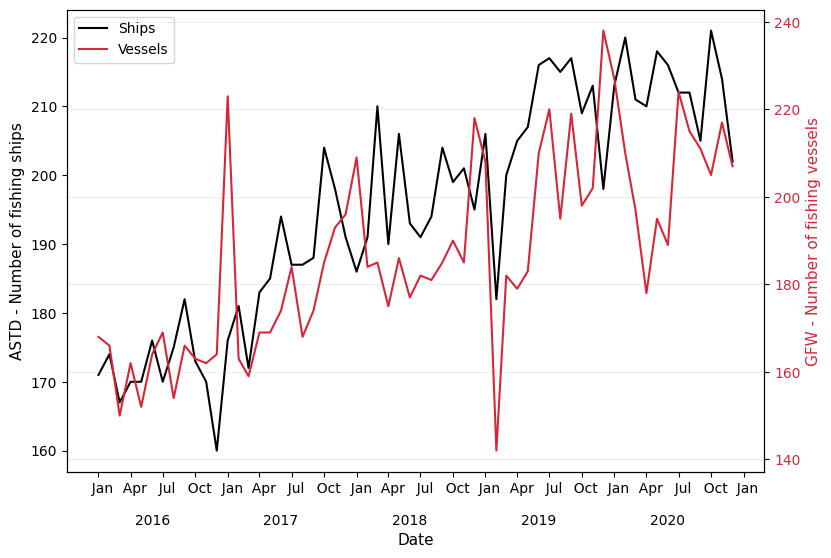

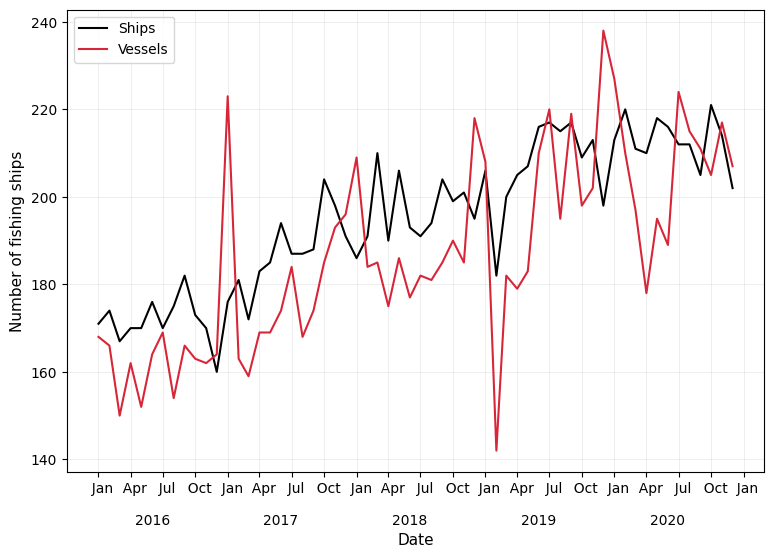

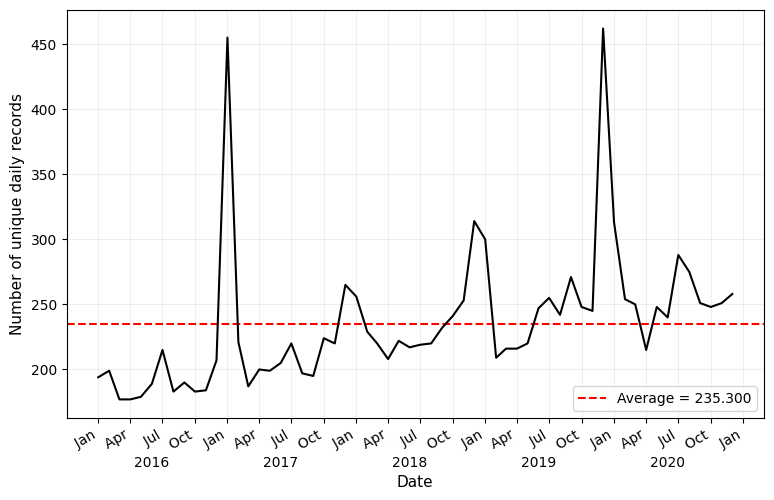

In [14]:
to_plot = dataHIGHLOGS.groupby('month')['shipid'].nunique()
to_plot2 = dataHIGHLOGS.groupby('month')['mmsi'].nunique()
evolution_permonth_both(to_plot, to_plot2, ylabels=["ASTD - Number of fishing ships", 'GFW - Number of fishing vessels'], label="MATCH-HIGHEST")
evolution_permonth_both_sameXY(to_plot, to_plot2, ylabels=["Number of fishing ships", 'vessels'], label="MATCH-HIGHEST-SAME_AXIS")

to_plot = dataHIGHLOGS.groupby('month').size()
evolution_permonth(to_plot, ylabel="Number of unique daily records", label="MATCH-HIGHEST")

##### Ratio analysis

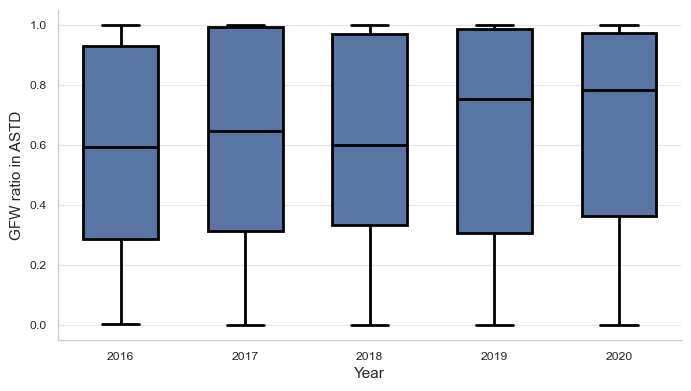

In [15]:
boxplot_(dataHIGHLOGS, 'year', 'ratio_gfw', ylabel="GFW ratio in ASTD", label="MATCH-HIGHEST")

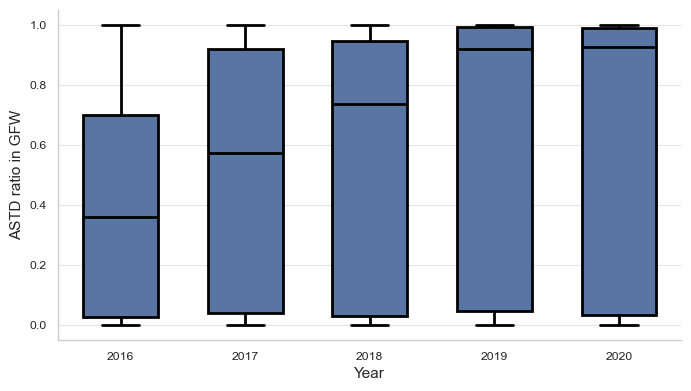

In [16]:
boxplot_(dataHIGHLOGS, 'year', 'ratio_astd', ylabel="ASTD ratio in GFW", label="MATCH-HIGHEST")

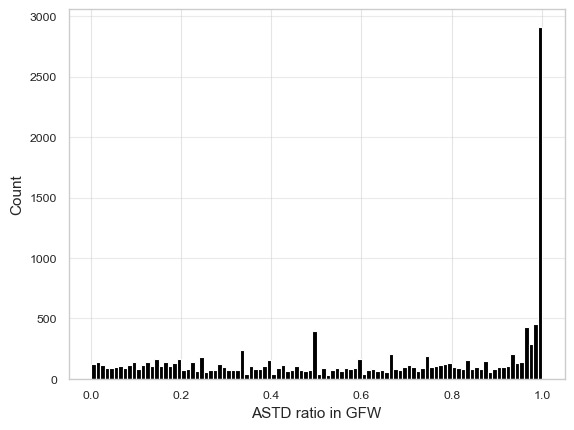

<module 'matplotlib.pyplot' from 'D:\\Projets\\env\\trackbuilder_env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [17]:
clean_bar(dataHIGHLOGS['ratio_gfw'], labels=['ASTD ratio in GFW', 'Count'], label="MATCH-HIGHEST-EXAMPLE", bins=100)

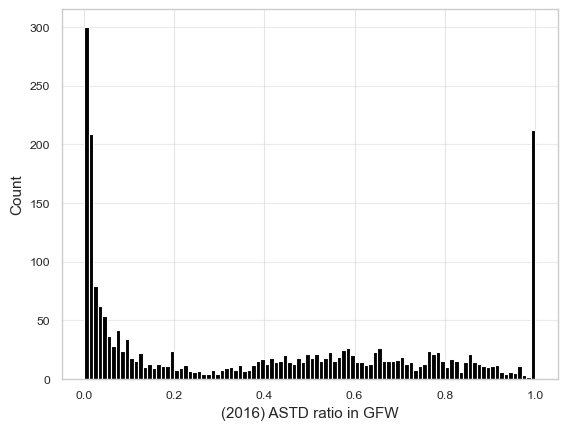

<module 'matplotlib.pyplot' from 'D:\\Projets\\env\\trackbuilder_env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [18]:
clean_bar(dataHIGHLOGS[dataHIGHLOGS["year"].astype(str) == "2016"]['ratio_astd'], labels=['(2016) ASTD ratio in GFW', 'Count'], label="MATCH-HIGHEST-EXAMPLE", bins=100)

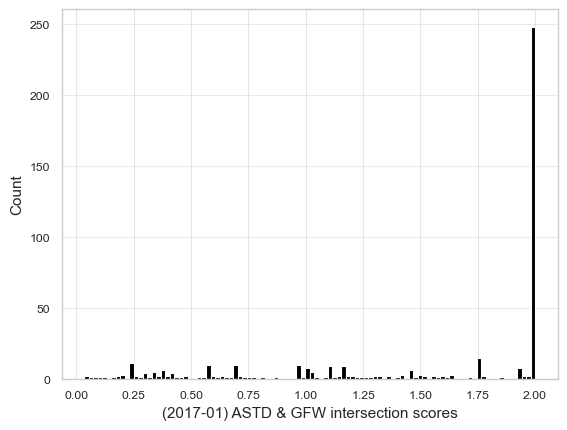

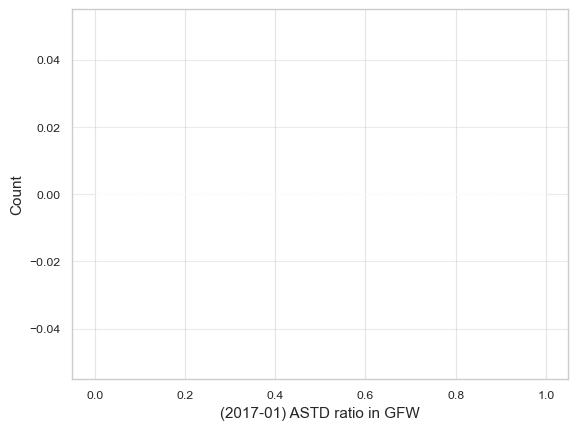

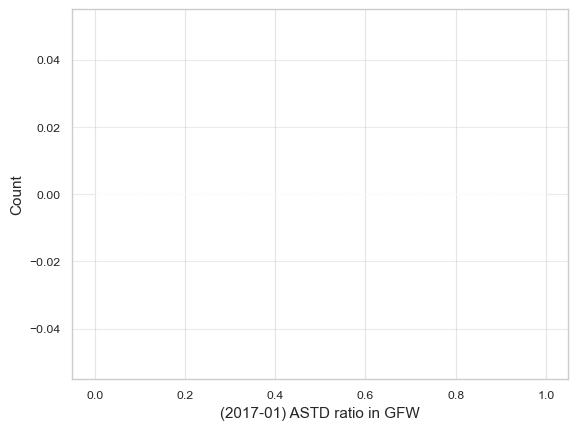

<module 'matplotlib.pyplot' from 'D:\\Projets\\env\\trackbuilder_env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [19]:
clean_bar(dataHIGHLOGS[dataHIGHLOGS["month"].astype(str) == "2017-01"]['score'], labels=['(2017-01) ASTD & GFW intersection scores', 'Count'], label="MATCH-HIGHEST-EXAMPLE",
          bins=100)

clean_bar(dataHIGHLOGS[dataHIGHLOGS["year"].astype(str) == "2017-01"]['ratio_astd'], labels=['(2017-01) ASTD ratio in GFW', 'Count'], label="MATCH-HIGHEST-EXAMPLE", bins=100)

clean_bar(dataHIGHLOGS[dataHIGHLOGS["year"].astype(str) == "2017-01"]['ratio_gfw'], labels=['(2017-01) ASTD ratio in GFW', 'Count'], label="MATCH-HIGHEST-EXAMPLE", bins=100)

#### Match after threshold

In [20]:
lat_threshold = 59

t_astd = 0.9
t_gfw_high = 0.6
t_gfw_low = 0.8
n_small = 20

dataLOGS = pd.read_csv(parquet_path + f"gfw_threshmatch2016_2020_LOGS.{lat_threshold}{[t_astd,t_gfw_low,t_gfw_high,n_small]}.csv")
# data= data[data['score']>=1.9]
dataLOGS['month'] = pd.PeriodIndex(dataLOGS['month'], freq='M')
dataLOGS['year'] = dataLOGS['month'].dt.year
dataLOGS

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,iceclass,sizegroup_gt,flagname,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid,year
0,273451570,2020-09,324,1274,1290,FS Ice Class 1C,< 1000 GT,Russia,1556,0.818766,0.987597,1.806363,1.806363,1.806363,2020
1,258535000,2020-10,1219,1301,1370,FS Ice Class 1B,1000 - 4999 GT,Norway,1513,0.859881,0.949635,1.809516,1.809516,1.809516,2020
2,251153000,2019-06,2031,1093,1145,FS Ice Class 1C,1000 - 4999 GT,Iceland,1490,0.733557,0.954585,1.688142,1.688142,1.688142,2019
3,251318000,2019-06,2591,1085,1139,FS Ice Class 1C,1000 - 4999 GT,Iceland,1436,0.755571,0.952590,1.708161,1.708161,1.708161,2019
4,258535000,2019-06,3657,1153,1170,FS Ice Class 1B,1000 - 4999 GT,Norway,1398,0.824750,0.985470,1.810220,1.810220,1.810220,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4638,257046460,2020-10,478,2,2,FS Ice Class 1A,1000 - 4999 GT,Norway,2,1.000000,1.000000,2.000000,2.000000,2.000000,2020
4639,231189000,2020-05,22009,2,2,FS Ice Class 1C,< 1000 GT,Faeroe Islands,2,1.000000,1.000000,2.000000,2.000000,2.000000,2020
4640,258205000,2018-07,7890,2,2,FS Ice Class 1C,< 1000 GT,Norway,2,1.000000,1.000000,2.000000,2.000000,2.000000,2018
4641,277558000,2019-05,15527,2,2,FS Ice Class 1B,1000 - 4999 GT,Lithuania,2,1.000000,1.000000,2.000000,2.000000,2.000000,2019


##### State after threshold only

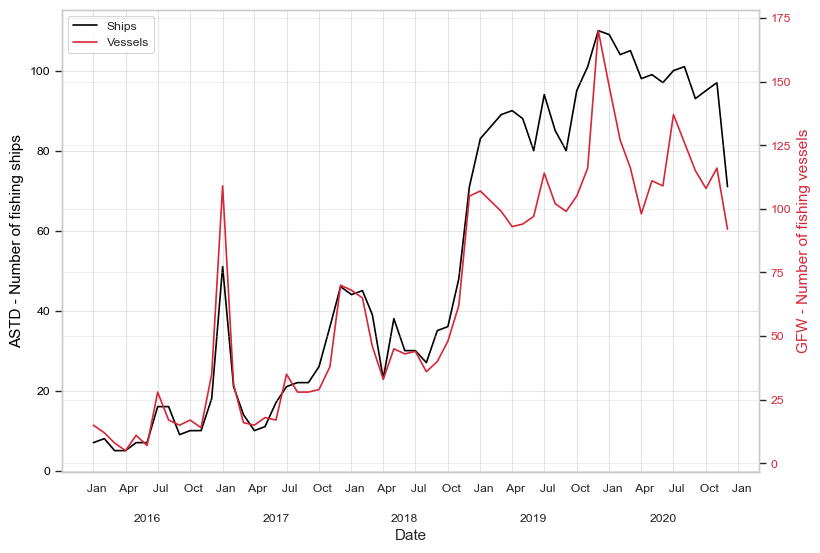

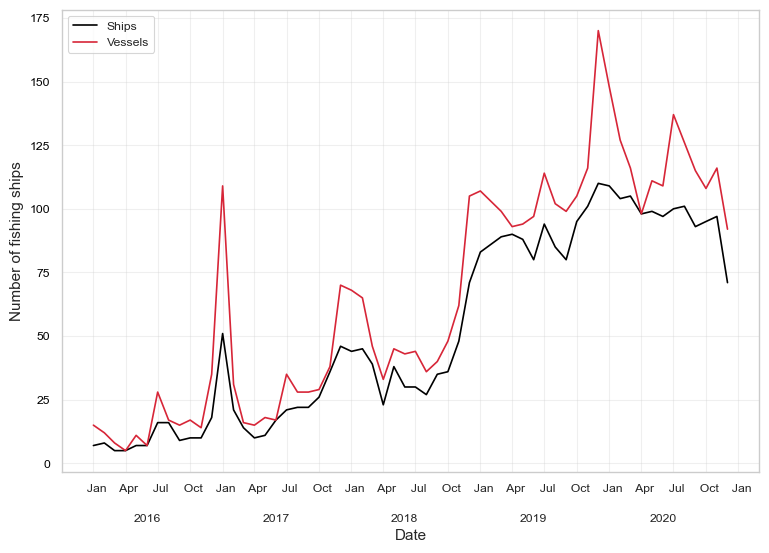

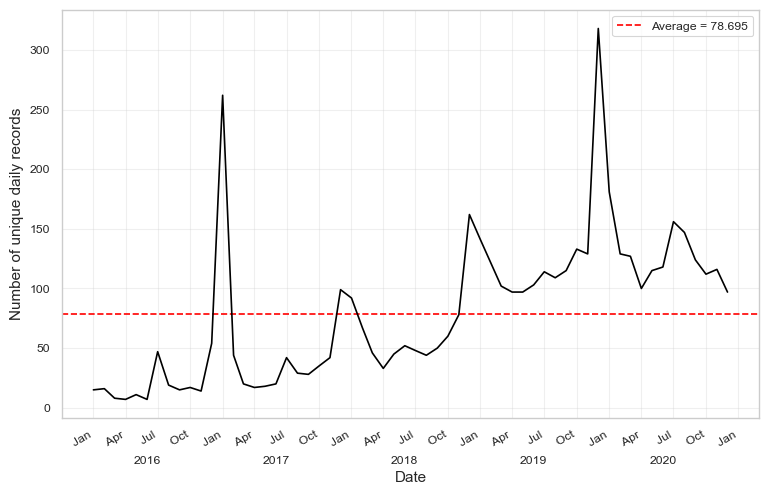

In [21]:
to_plot = dataLOGS.groupby('month')['shipid'].nunique()
to_plot2 = dataLOGS.groupby('month')['mmsi'].nunique()
evolution_permonth_both(to_plot, to_plot2, ylabels=["ASTD - Number of fishing ships", 'GFW - Number of fishing vessels'], label="MATCH-THRESHOLD")
evolution_permonth_both_sameXY(to_plot, to_plot2, ylabels=["Number of fishing ships", 'vessels'], label="MATCH-THRESHOLD-SAME_AXIS")

to_plot = dataLOGS.groupby('month').size()
evolution_permonth(to_plot, ylabel="Number of unique daily records", label="MATCH-THRESHOLD")

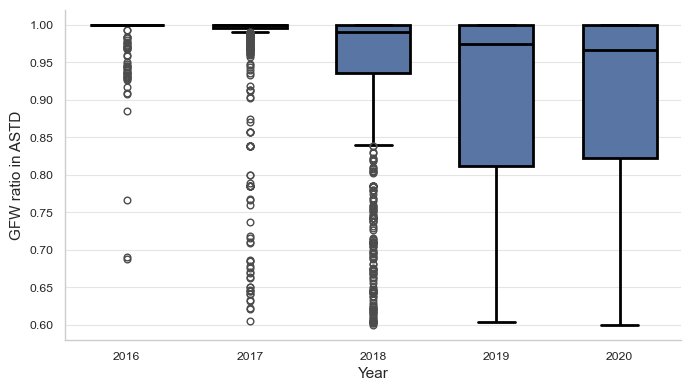

In [22]:
boxplot_(dataLOGS, 'year', 'ratio_gfw', ylabel="GFW ratio in ASTD", label="MATCH-THRESHOLD")

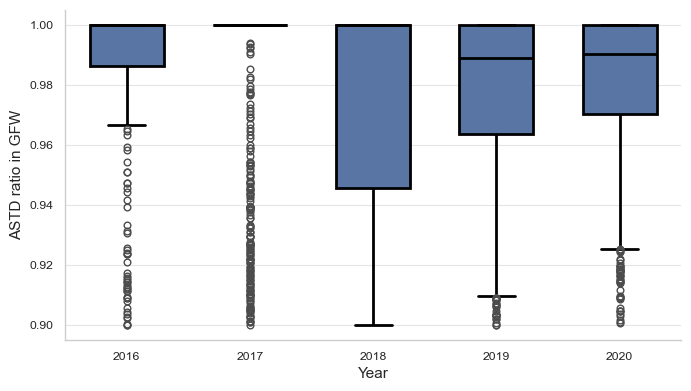

In [23]:
boxplot_(dataLOGS, 'year', 'ratio_astd', ylabel="ASTD ratio in GFW", label="MATCH-THRESHOLD")

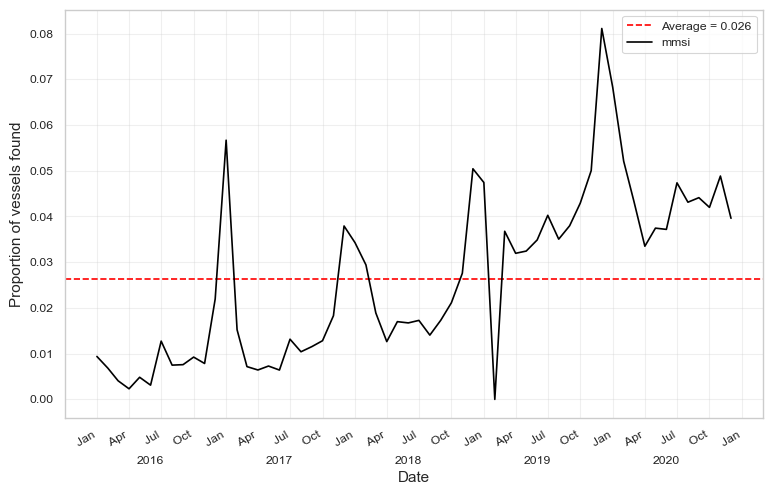

In [24]:
 # temp = merged.groupby('month')['mmsi'].nunique()
temp = dataLOGS.groupby('month')['mmsi'].nunique()
by_month = gfw_work.groupby('month')['mmsi'].nunique()

ratios = temp / by_month
ratios = ratios.fillna(0)

evolution_permonth(ratios, ylabel="Proportion of vessels found", label="MATCH-THRESHOLD")

#### Full match with threshold and class verification

In [25]:
lat_threshold = 59

t_astd = 0.9
t_gfw_high = 0.6
t_gfw_low = 0.8
n_small = 20

data = pd.read_csv(parquet_path + f"gfw_threshmatch2016_2020.{lat_threshold}{[t_astd,t_gfw_low,t_gfw_high,n_small]}.csv")
# data= data[data['score']>=1.9]
data['month'] = pd.PeriodIndex(data['month'], freq='M')
data['year'] = data['month'].dt.year
data

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,iceclass,sizegroup_gt,flagname,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid,year
0,273451570,2020-09,324,1274,1290,FS Ice Class 1C,< 1000 GT,Russia,1556,0.818766,0.987597,1.806363,1.806363,1.806363,2020
1,258535000,2020-10,1219,1301,1370,FS Ice Class 1B,1000 - 4999 GT,Norway,1513,0.859881,0.949635,1.809516,1.809516,1.809516,2020
2,251153000,2019-06,2031,1093,1145,FS Ice Class 1C,1000 - 4999 GT,Iceland,1490,0.733557,0.954585,1.688142,1.688142,1.688142,2019
3,251318000,2019-06,2591,1085,1139,FS Ice Class 1C,1000 - 4999 GT,Iceland,1436,0.755571,0.952590,1.708161,1.708161,1.708161,2019
4,258535000,2019-06,3657,1153,1170,FS Ice Class 1B,1000 - 4999 GT,Norway,1398,0.824750,0.985470,1.810220,1.810220,1.810220,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,257046460,2020-10,478,2,2,FS Ice Class 1A,1000 - 4999 GT,Norway,2,1.000000,1.000000,2.000000,2.000000,2.000000,2020
4000,231189000,2020-05,22009,2,2,FS Ice Class 1C,< 1000 GT,Faeroe Islands,2,1.000000,1.000000,2.000000,2.000000,2.000000,2020
4001,258205000,2018-07,7890,2,2,FS Ice Class 1C,< 1000 GT,Norway,2,1.000000,1.000000,2.000000,2.000000,2.000000,2018
4002,277558000,2019-05,15527,2,2,FS Ice Class 1B,1000 - 4999 GT,Lithuania,2,1.000000,1.000000,2.000000,2.000000,2.000000,2019


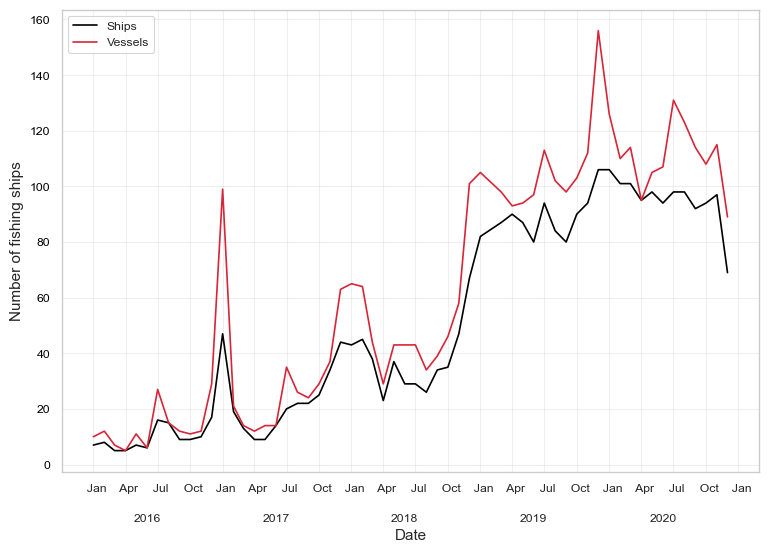

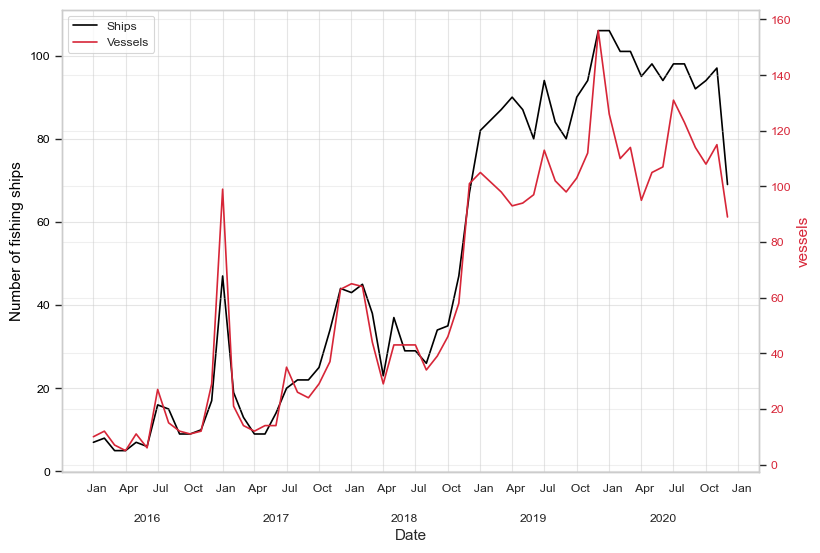

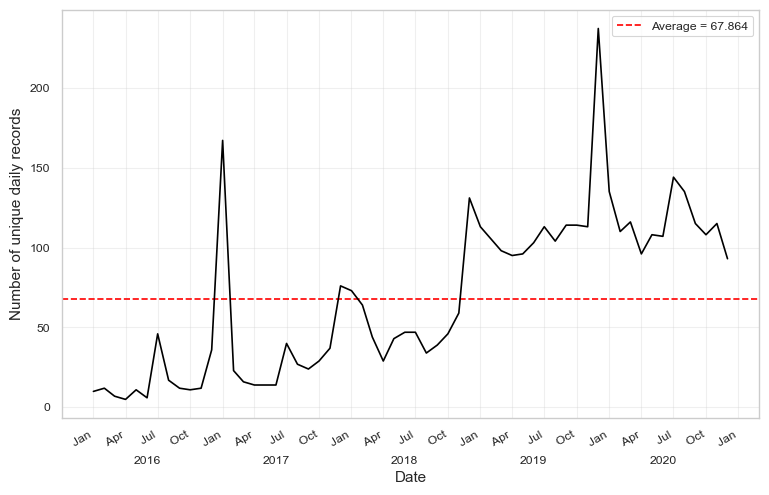

In [26]:
to_plot = data.groupby('month')['shipid'].nunique()
to_plot2 = data.groupby('month')['mmsi'].nunique()
evolution_permonth_both_sameXY(to_plot, to_plot2, ylabels=["Number of fishing ships", 'vessels'], label="MATCH-FINAL-SAME_AXIS")
evolution_permonth_both(to_plot, to_plot2, ylabels=["Number of fishing ships", 'vessels'], label="MATCH-FINAL")

to_plot = data.groupby('month').size()
evolution_permonth(to_plot, ylabel="Number of unique daily records", label="MATCH-FINAL")

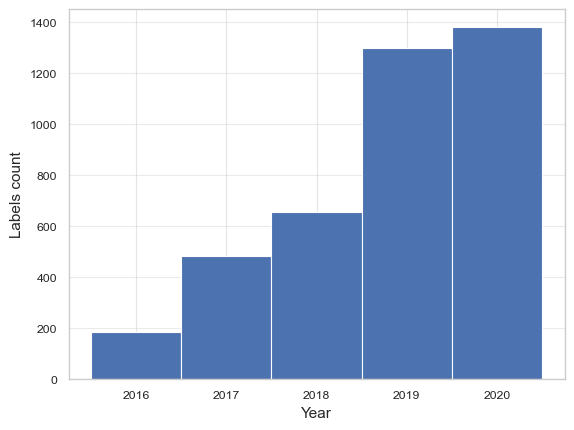

<module 'matplotlib.pyplot' from 'D:\\Projets\\env\\trackbuilder_env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [27]:
clean_bar(data['year'], labels=['Year', 'Labels count'], label="MATCH-FINAL", color="#4C72B0")

##### Explorations

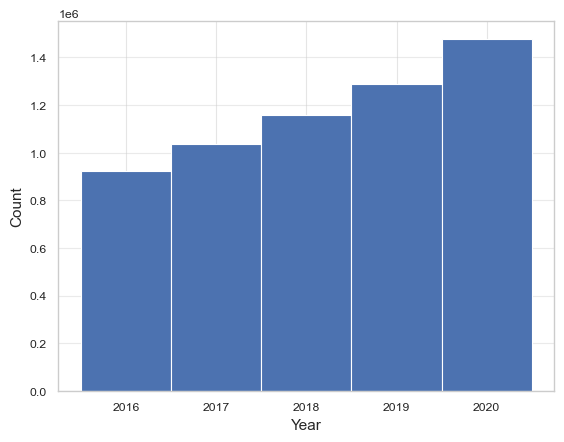

<module 'matplotlib.pyplot' from 'D:\\Projets\\env\\trackbuilder_env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [28]:
clean_bar(df_astd['month'].dt.year, labels=['Year', 'Count'], label="MATCH-FINAL-EXPLORE", color="#4C72B0")

###### GFW

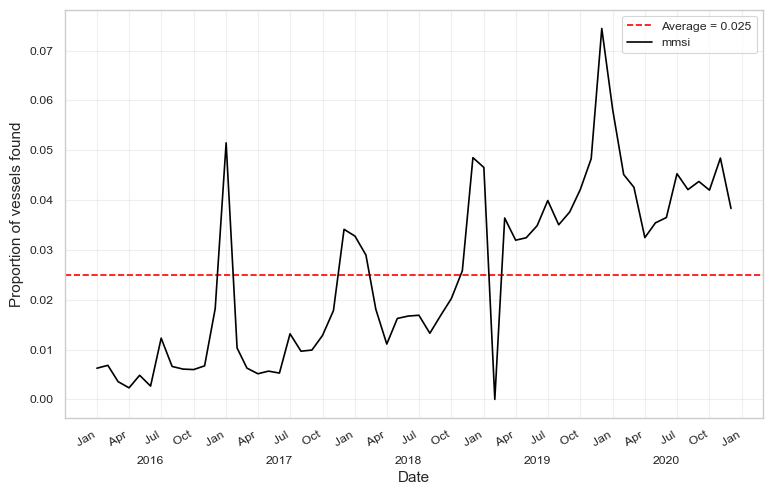

In [29]:
match = data.groupby('month')['mmsi'].nunique()
by_month = gfw_work.groupby('month')['mmsi'].nunique()

ratios = match / by_month
ratios = ratios.fillna(0)

evolution_permonth(ratios, ylabel="Proportion of vessels found", label="MATCH-FINAL-EXPLORE")

###### ASTD

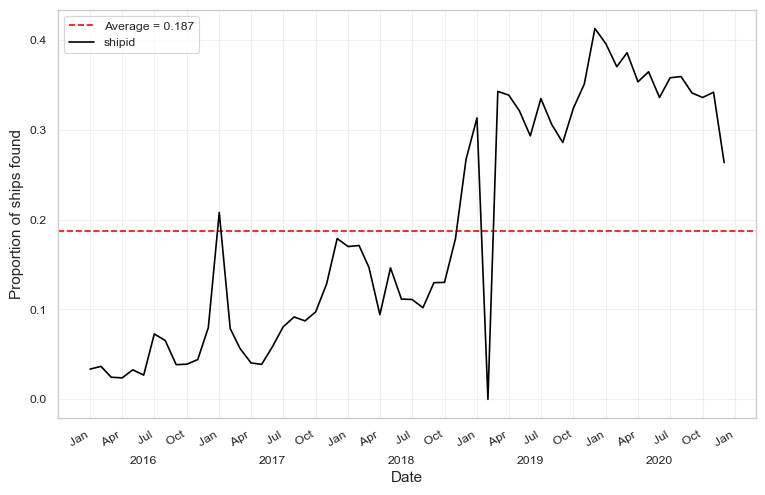

In [30]:
match = data.groupby('month')['shipid'].nunique()
by_month = df_astd.groupby('month')['shipid'].nunique()

ratios = match / by_month
ratios = ratios.fillna(0)

evolution_permonth(ratios, ylabel="Proportion of ships found", label="MATCH-FINAL-EXPLORE")

###### Both

In [31]:
# # c1 = data['month'].dt.year.value_counts().sort_index()
# # c2 = df_astd['month'].dt.year.value_counts().sort_index()
# # c3 = gfw_work['month'].dt.year.value_counts().sort_index()
#
# c1 = data['month'].value_counts().sort_index()
# c2 = df_astd['month'].value_counts().sort_index()
# c3 = gfw_work['month'].value_counts().sort_index()
#
# counts = pd.concat([c1, c2, c3], axis=1)
# counts.columns = ['df', 'df_astd', 'gfw']
#
# ratio_df_astd = counts['df'] / counts['df_astd']
# ratio_df_gfw  = counts['df'] / counts['gfw']
#
# plt.figure(figsize=(10, 5))
#
# plt.plot(ratio_df_astd.index.to_timestamp(), ratio_df_astd,
#          marker='o', label='df / df_astd')
#
# plt.plot(ratio_df_gfw.index.to_timestamp(), ratio_df_gfw,
#          marker='s', label='df / gfw')
#
# # Auto-zoom y-axis
# ymin = min(ratio_df_astd.min(), ratio_df_gfw.min())
# ymax = max(ratio_df_astd.max(), ratio_df_gfw.max())
# margin = (ymax - ymin) * 0.1
# plt.ylim(max(0, ymin - margin), ymax + margin)
#
# plt.xlabel("Year")
# plt.ylabel("Ratio")
# plt.title("Yearly Ratios")
# plt.legend()
# plt.grid(alpha=0.3)
#
# plt.tight_layout()
#
# filename = f"{"MATCH-FINAL-EXPLORE"}{"Year"}_{"Ratio"}"
# path = os.path.join("300DPI", filename + ".png")
#
# if os.path.exists(path):
#     i = 1
#     while os.path.exists(os.path.join("300DPI", f"{filename}_{i}.png")):
#         i += 1
#     plt.savefig(os.path.join("300DPI", f"{filename}_{i}.png"), dpi=300)
# else:
#     plt.savefig(path, dpi=300)
#
# plt.show()

## Count of unique MMSI & other metrics

In [32]:
df = data.copy()

print("Total size (unique shipid):", df[['shipid', 'month']].drop_duplicates().shape[0])
print("Total distinct months (mmsi) :", df[['mmsi', 'month']].drop_duplicates().shape[0])
print("Total mmsi :", df['mmsi'].nunique())
df_pct = ( # Pourcentage, of how many mmsi have 12, 11, 10 ... matched months
    df
    .groupby('mmsi')['month']
    .nunique()
    .value_counts(normalize=True)
    .mul(100)
    .rename('percent')
    .reset_index(name='percent')
    .rename(columns={'index': 'n_months'})
)

display(df_pct.head(5))

df.head(5)

Total size (unique shipid): 2962
Total distinct months (mmsi) : 3662
Total mmsi : 531


,month,percent
0,1,41.054614
1,2,14.124294
2,3,9.227872
3,4,5.649718
4,5,3.389831


,mmsi,month,shipid,match_n_mmsi,astd_n_ship,iceclass,sizegroup_gt,flagname,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid,year
0,273451570,2020-09,324,1274,1290,FS Ice Class 1C,< 1000 GT,Russia,1556,0.818766,0.987597,1.806363,1.806363,1.806363,2020
1,258535000,2020-10,1219,1301,1370,FS Ice Class 1B,1000 - 4999 GT,Norway,1513,0.859881,0.949635,1.809516,1.809516,1.809516,2020
2,251153000,2019-06,2031,1093,1145,FS Ice Class 1C,1000 - 4999 GT,Iceland,1490,0.733557,0.954585,1.688142,1.688142,1.688142,2019
3,251318000,2019-06,2591,1085,1139,FS Ice Class 1C,1000 - 4999 GT,Iceland,1436,0.755571,0.952590,1.708161,1.708161,1.708161,2019
4,258535000,2019-06,3657,1153,1170,FS Ice Class 1B,1000 - 4999 GT,Norway,1398,0.824750,0.985470,1.810220,1.810220,1.810220,2019


## Get mmsi count with distinct month

Total of different mmsi : 531
Total of different shipid : 2168


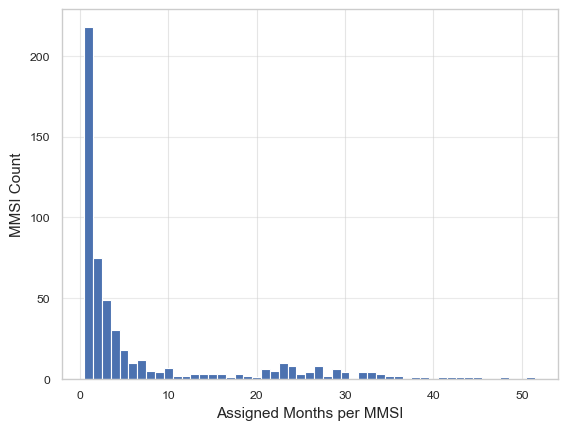

Total number of MMSI unique month assigned : 3662
Average number of unique month assigned per MMSI : 6.8964218455743875


In [33]:
print("Total of different mmsi :", data['mmsi'].nunique())
print("Total of different shipid :", data['shipid'].nunique())

to_plot = data.groupby("mmsi")['month'].nunique()
clean_bar(data=to_plot, labels=["Assigned Months per MMSI", "MMSI Count"], label="MATCH-FINAL-EXPLORE", color="#4C72B0")

avg_per_mmsi = data[['mmsi', 'month']].drop_duplicates()
print("Total number of MMSI unique month assigned :", avg_per_mmsi.shape[0])

seg_per_mmsi = avg_per_mmsi.groupby("mmsi")['month'].nunique()
print("Average number of unique month assigned per MMSI :", seg_per_mmsi.mean())

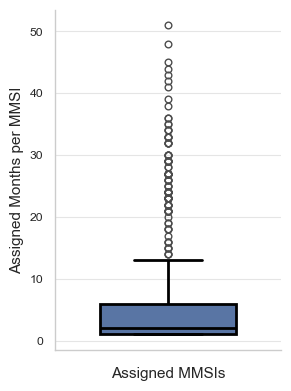

In [34]:
boxplot_(seg_per_mmsi, x=None, y=None, xlabel="Assigned MMSIs", ylabel="Assigned Months per MMSI", label="MATCH-FINAL-EXPLORE", size=(3,4))

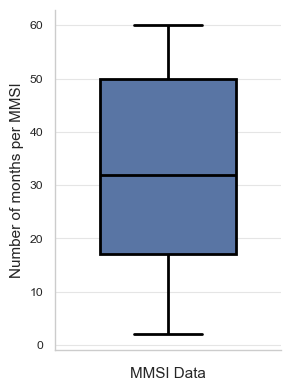

In [35]:
gfw_count = gfw_work.groupby('mmsi')['month'].nunique()
boxplot_(gfw_count, x=None, y=None, xlabel="MMSI Data", ylabel="Number of months per MMSI", label="MATCH-FINAL-EXPLORE", size=(3,4))